In [10]:
# 1. General Data & Math Tools
import pandas as pd # For handling our ticket tables
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt # For charts
import seaborn as sns # For making charts look professional

# 2. Text Cleaning Tools (NLP Specific)
import re # 'Regular Expressions' - used to strip out punctuation/symbols
import nltk # The 'Natural Language Toolkit' for language processing
from nltk.corpus import stopwords # To get a list of 'useless' words like 'the', 'a', 'is'

# 3. The 'Translator' (Turning words into numbers)
from sklearn.feature_extraction.text import TfidfVectorizer

# 4. The 'Brain' (Machine Learning Model)
from sklearn.model_selection import train_test_split # To split data for testing
from sklearn.naive_bayes import MultinomialNB # The Classifier algorithm
from sklearn.metrics import classification_report, confusion_matrix # To see our score

# Download the list of English stop words (only needs to be done once)
nltk.download('stopwords')

print("Task 2 Environment is ready!")

Task 2 Environment is ready!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mymsi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
import re
from nltk.corpus import stopwords

# Get the list of English stop words (like 'the', 'is', 'in')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Convert to Lowercase (so 'Internet' and 'internet' are the same)
    text = text.lower()
    
    # 2. Remove Punctuation and Numbers (using 're' regular expressions)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. Split into individual words
    words = text.split()
    
    # 4. Remove 'Stop Words' (words that don't add meaning)
    important_words = [w for w in words if w not in stop_words]
    
    # 5. Join them back into a clean string
    return " ".join(important_words)

# --- TEST IT ---
test_sentence = "Help! My internet is very slow, and I am unhappy."
print(f"Original: {test_sentence}")
print(f"Cleaned:  {clean_text(test_sentence)}")

Original: Help! My internet is very slow, and I am unhappy.
Cleaned:  help internet slow unhappy


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Our sample data from before
sample_tickets = [
    "internet connection slow",
    "need refund bill",
    "reset account password",
    "router turning",
    "overcharged month",
    "cannot log profile"
]

# Initialize the Translator
vectorizer = TfidfVectorizer()

# Transform the words into numbers
X_matrix = vectorizer.fit_transform(sample_tickets)

print("Vocabulary learned by the model:")
print(vectorizer.get_feature_names_out())
print("\nShape of the Matrix (6 tickets x number of unique words):")
print(X_matrix.shape)

Vocabulary learned by the model:
['account' 'bill' 'cannot' 'connection' 'internet' 'log' 'month' 'need'
 'overcharged' 'password' 'profile' 'refund' 'reset' 'router' 'slow'
 'turning']

Shape of the Matrix (6 tickets x number of unique words):
(6, 16)


In [13]:
from sklearn.naive_bayes import MultinomialNB

# 1. Our 'Answers' (Labels) for the 6 tickets
categories = ["Technical", "Billing", "Account", "Technical", "Billing", "Account"]

# 2. Initialize the Brain
clf = MultinomialNB()

# 3. Train the Brain (Fit the matrix to the categories)
clf.fit(X_matrix, categories)

print("The Robot Secretary is now trained on 6 samples!")

The Robot Secretary is now trained on 6 samples!


In [15]:
# 1. A new, unseen ticket
new_ticket = ["I am angry because my monthly bill is too high"]

# 2. We MUST transform the new ticket into numbers using the SAME vectorizer
new_ticket_cleaned = [clean_text(new_ticket[0])] # Use our cleaning function
new_X = vectorizer.transform(new_ticket_cleaned)

# 3. Make the prediction
prediction = clf.predict(new_X)

print(f"New Ticket: {new_ticket[0]}")
print(f"Robot Prediction: {prediction[0]}")

New Ticket: I am angry because my monthly bill is too high
Robot Prediction: Billing


In [16]:
from sklearn.datasets import fetch_20newsgroups

# We will only pick 'Tech' related categories to simulate support tickets
categories = [
    'comp.sys.mac.hardware',   # Mac Support
    'comp.sys.ibm.pc.hardware',# PC Support
    'comp.graphics',           # Software/Graphics Support
    'sci.electronics'          # Hardware/Electronics Support
]

# Download the dataset
data_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

# Convert to a DataFrame so it's easy to read
df = pd.DataFrame({'ticket_text': data_train.data, 'category': data_train.target})

# Map the numbers back to names
target_names = data_train.target_names
df['category_name'] = df['category'].apply(lambda x: target_names[x])

print(f"Downloaded {len(df)} support tickets!")
df.head()

Downloaded 2343 support tickets!


,ticket_text,category,category_name
0,I hear that the Performa 450 is really an LCII...,2,comp.sys.mac.hardware
1,"\nThe ??-jumper is used, if the other drive a ...",1,comp.sys.ibm.pc.hardware
2,"Hi again,\n\nMany thanks to all the people who...",0,comp.graphics
3,I'm considering adding a floptical drive to my...,2,comp.sys.mac.hardware
4,\n\nWhat's the latest version of Stepping Out ...,2,comp.sys.mac.hardware


In [18]:
# 1. Make sure the cleaning function is defined (Run this just in case)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    important_words = [w for w in words if w not in stop_words]
    return " ".join(important_words)

# 2. CREATE the missing column
print("Creating the 'clean_text' column now...")
df['clean_text'] = df['ticket_text'].apply(clean_text)

# 3. Double check it exists
print("Columns currently in df:", df.columns.tolist())
df[['ticket_text', 'clean_text']].head()

Creating the 'clean_text' column now...
Columns currently in df: ['ticket_text', 'category', 'category_name', 'clean_text']


,ticket_text,clean_text
0,I hear that the Performa 450 is really an LCII...,hear performa really lciii internal modem mode...
1,"\nThe ??-jumper is used, if the other drive a ...",jumper used drive conner cpxxx jumper set driv...
2,"Hi again,\n\nMany thanks to all the people who...",hi many thanks people responded request ms win...
3,I'm considering adding a floptical drive to my...,im considering adding floptical drive current ...
4,\n\nWhat's the latest version of Stepping Out ...,whats latest version stepping works ok


In [19]:
# Now this should work perfectly!
X = df['clean_text']
y = df['category_name']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Success! Training on {len(X_train)} samples.")

Success! Training on 1874 samples.


In [20]:
# Initialize the Translator
tfidf = TfidfVectorizer()

# 1. Learn the vocabulary from the Training set
X_train_tfidf = tfidf.fit_transform(X_train)

# 2. Transform the Test set using the SAME vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("Total unique words found in the tickets:", len(tfidf.get_feature_names_out()))

Total unique words found in the tickets: 18468


In [21]:
# 1. Initialize the Brain
nb_model = MultinomialNB()

# 2. Train the Brain
nb_model.fit(X_train_tfidf, y_train)

# 3. Make predictions on our 'Exam' (X_test)
y_pred = nb_model.predict(X_test_tfidf)

print("The model has finished classifying the test tickets!")

The model has finished classifying the test tickets!


--- Classification Report ---
                          precision    recall  f1-score   support

           comp.graphics       0.77      0.85      0.80       104
comp.sys.ibm.pc.hardware       0.80      0.81      0.80       129
   comp.sys.mac.hardware       0.73      0.76      0.74       108
         sci.electronics       0.88      0.75      0.81       128

                accuracy                           0.79       469
               macro avg       0.79      0.79      0.79       469
            weighted avg       0.80      0.79      0.79       469



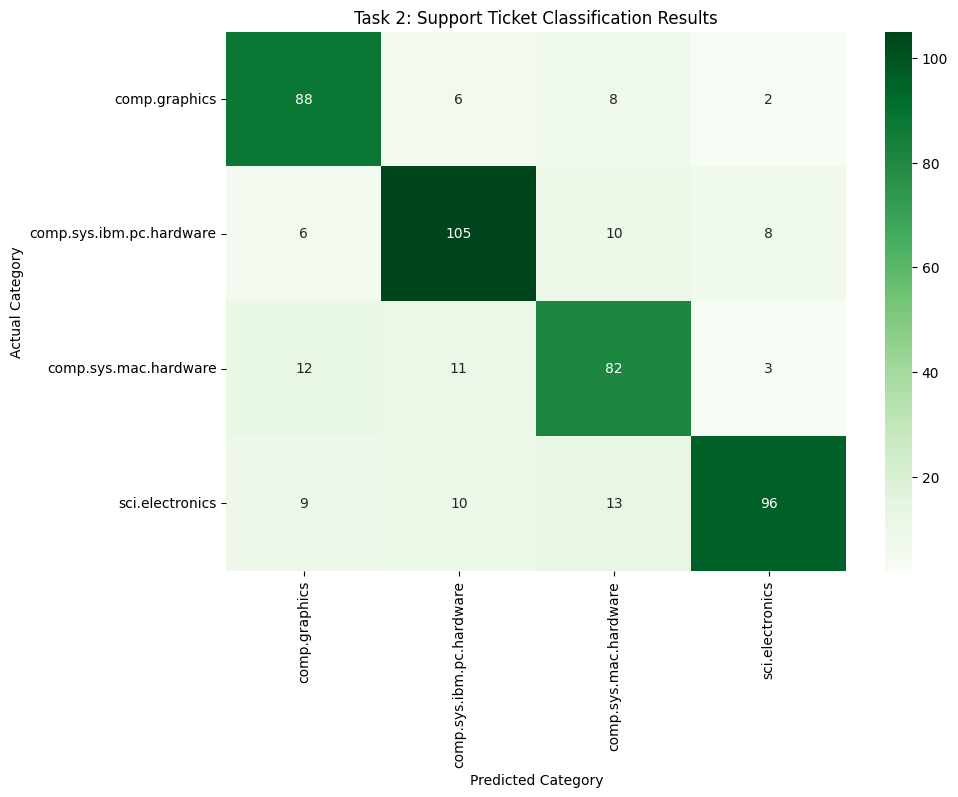

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualize the Results
plt.figure(figsize=(10,7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=nb_model.classes_, 
            yticklabels=nb_model.classes_)
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Task 2: Support Ticket Classification Results')
plt.show()